# Calling genotypes, prevalences and filtering data
This program analyzes tables of counts. In the prior "variant calling" step of the program, mutation counts were generated for each sample by annotating the VCF file generated by freebayes, using SNPEff to assign amino acid names to mutations.

The count tables are intended to be as "raw" as possible. In this part of the analysis we will:
1. apply various filters to the count tables, considering a mutation 'sampled' for a sample if it passes the filters for that sample.
2. choose the level of detail of geographic locations we care about from a metadata file
3. summarize the number of filtered samples at each location that had the mutation and the total number of filtered samples at each location, where the 'prevalence' of a mutation at a location is the first number divided by the second number
4. graph the prevalences and filtered sample sizes on a map
5. (optional) - apply additional filtering for re-evaluation of prevalence data.

In [1]:
# Edit
output_folder = 'miptools_output'
mutation_count_file = "input/alternate_AA_table.csv"
mutation_coverage_file = "input/coverage_AA_table.csv"
metadata_table = "input/PRX-07_metadata.csv"

# how many reads (or, more accurately, UMIs) do we need spanning the genomic coordinates of a mutation in order to
# consider the coordinates "sequenced" for a given sample? If UMI count is below min_coverage, the sample will be
# marked as "missing" for the mutation of interest.
min_coverage = 3

# If min_coverage is achieved in the sample, how many UMIs do we need that support the mutant (or alternate) allele
# in order to consider the alternate allele "present" in the sample? Otherwise if min_coverage is surpassed but
# min_count is not, the sample will be marked as matching the reference allele.
min_count = 1

# Is there a number that min_count/min_coverage needs to surpass before we consider an alternate allele "present" in a
# sample? Our usual answer is 'no' so we generally set this to '0' - but you may not want to count an alternate allele
# present if it's found in a very low fraction of the UMIs associated with a sample, even if the absolute number of UMIs
# associated with the alternate allele is above your threshold.
min_freq = 0

# Don't Edit below
import sys
import importlib
sys.path.append("src")
import background as bg
importlib.reload(bg)
all_columns, mutation_dict, filtered_mutations, mutation_counts, mutation_coverage = bg.get_mutation_counts(mutation_count_file, mutation_coverage_file)
print('observed missense mutations are:')
print(filtered_mutations)
print('')
metadata_columns = bg.get_metadata_columns(metadata_table)
print('metadata columns are: ')
print(metadata_columns)

observed missense mutations are:
['crt-Asp17Glu', 'crt-Asp24Tyr', 'crt-Ala45Val', 'crt-Cys72Ser', 'Crt-Val73Leu', 'crt-Met74Ile', 'crt-Asn75Glu', 'crt-Lys76Thr', 'crt-Thr93Ser', 'crt-His97Leu', 'crt-His97Tyr', 'crt-Cys101Phe', 'crt-Phe145Ile', 'crt-Ile218Phe', 'crt-Ala220Ser', 'crt-Gln271Glu', 'crt-Asn326Ser', 'crt-Met343Leu', 'crt-Gly353Val', 'crt-Ile356Thr', 'crt-Arg371Ile', 'dhfr-ts-Ala16Val', 'dhfr-ts-Asn51Ile', 'dhfr-ts-Cys59Arg', 'dhfr-ts-Ser108Asn', 'dhfr-ts-Ser108Thr', 'dhfr-ts-Ile164Leu', 'dhps-Ile431Val', 'dhps-Ser436Ala', 'dhps-Ser436Phe', 'dhps-Ala437Gly', 'dhps-Lys540Glu', 'dhps-Ala581Gly', 'dhps-Ala613Ser', 'dhps-Ala613Thr', 'k13-Lys108Glu', 'k13-His136Asn', 'k13-Thr149Ser', 'k13-Lys189Asn', 'k13-Lys189Thr', 'k13-Arg255Lys', 'k13-Leu258Met', 'k13-Gln271His', 'k13-Thr348Ile', 'k13-Pro441Leu', 'k13-Phe446Ile', 'k13-Gly449Ala', 'k13-Asn458Tyr', 'k13-Cys469Phe', 'k13-Cys469Tyr', 'k13-Met476Ile', 'k13-Ala481Val', 'k13-Asn490Thr', 'k13-Tyr493His', 'k13-Arg515Lys', 'k13-Pro527Hi

In [2]:
# In the metadata sheet (reproduced in the table output from the cell above), which column contains sample names and
# which column contains the names of the locations you'd like to plot (or summarize by)?
sample_column='Sampleid'
summary_column='district'

# Which mutations would you like to graph? A full list of sequenced plus key mutations from targets.tsv is created when
#you run the code in the cell above - this outputs the full list of available mutations to choose from.

#example if you want only "key mutations from the targets.tsv file found in the project_resources folder" plus k13 mutations
#mutation_column=open('/opt/project_resources/targets.tsv').readline().strip().split('\t').index('mutation_name')
#mutations_of_interest=[line.strip().split('\t')[mutation_column] for line in open('/opt/project_resources/targets.tsv')][1:]
#k13_muts=[mut for mut in filtered_mutations if 'k13' in mut]
#mutations_of_interest+=['dhps-Ala437Gly'] #targets.tsv file seems to be missing this key mutation
#mutations_of_interest+=k13_muts #add any additional found k13 mutations
#mutations_of_interest=list(set(mutations_of_interest)) #remove any duplicates

#example if you want only mutations from the AA tables from a specific gene
#mutations_of_interest=[mutation for mutation in filtered_mutations if 'k13' in mutation]

#example if you want to manually set the mutations to analyze
# mutations_of_interest=[
# 'dhfr-ts-Asn51Ile', 'dhfr-ts-Cys59Arg', 'dhfr-ts-Ser108Asn', 'dhfr-ts-Ile164Leu',
# 'mdr1-Asn652Asp', 'mdr1-Asn86Tyr', 'mdr1-Asp1246Tyr', 'mdr1-Asp650Asn',
# 'mdr1-Tyr184Phe', 'crt-Met74Ile', 'crt-Asn75Glu', 'crt-Lys76Thr',
# 'crt-Gln271Glu', 'crt-Arg371Ile', 'dhps-Ala437Gly', 'dhps-Lys540Glu',
# 'dhps-Ala581Gly', 'k13-Arg561His']

mutations_of_interest=[
    'crt-Lys76Thr',
    'k13-Arg561His',
    'dhfr-ts-Ile164Leu',
    'dhps-Ala581Gly',
    'mdr1-Asn86Tyr'
]

#the reformatted counts file is either prevalences_input_table.csv (if you want to calculate prevalences) or
#within_sample_allele_frequencies.tsv (if you want to calculate average allele frequencies). You should comment in one
#line or the other, and leave the other one commented out.
#reformatted_counts_file='prevalences_input_table.csv'
reformatted_counts_file='within_sample_allele_frequencies.csv'

# don't edit
bg.create_prevalences_input_table(mutations_of_interest, mutation_dict, all_columns, mutation_counts, mutation_coverage, output_folder, min_count, min_coverage, min_freq)
prevalences = bg.calculate_prevalences(output_folder, metadata_table, reformatted_counts_file, sample_column, summary_column, mutations_of_interest)
prevalences.head(10)

,Latitude,Longitude,crt-Lys76Thr,k13-Arg561His,dhfr-ts-Ile164Leu,dhps-Ala581Gly,mdr1-Asn86Tyr
district,,,,,,,
Agago,2.919026,33.337057,0 (0/20),0 (0/20),0.05 (1/20),0 (0/20),0 (0/19)
Amolatar,1.637470,32.843809,0 (0/11),0 (0/15),1.0 (8/8),0 (0/16),0 (0/16)
Kabale,-1.288973,29.996121,0 (0/20),0.3604 (7.2077/20),0.5331 (10.662/20),0.6943 (13.8866/20),0 (0/20)
Kole,2.266009,32.774374,0 (0/20),0 (0/19),0.0581 (1.1041/19),0 (0/20),0 (0/20)
overall,NaN,NaN,0 (0/71),0.0974 (7.2077/74),0.3099 (20.7661/67),0.1827 (13.8866/76),0 (0/75)


# Plot Scatter map

In [3]:
#loads a dropdown menu so a user can choose one mutation of interest to graph
# RUN
import os
import ipywidgets as widgets
variants_of_interest=open(os.path.join(output_folder, "prevalence_summary.tsv")).readline().strip().split('\t')[3:]
variant = widgets.Dropdown(
    options=variants_of_interest,
    description='variant:',
    disabled=False,
)
# Don't edit
country, country_shortcuts = bg.generate_country_dropdown()
write_detail_files_checkbox = widgets.Checkbox(value=False, description='Write detail files')
use_geojson_checkbox = widgets.Checkbox(value=True, description='Use country GeoJSON')
overlay_water_checkbox = widgets.Checkbox(value=True, description='Overlay water')
highlight_chosen_country_checkbox = widgets.Checkbox(value=True, description='Highlight chosen country')
print("Country and Variant of Interest:\n")
display(widgets.VBox([
    widgets.HBox([country, variant]),
    widgets.HBox([write_detail_files_checkbox, use_geojson_checkbox]),
    widgets.HBox([overlay_water_checkbox, highlight_chosen_country_checkbox])
]))

Country and Variant of Interest:



5.77741180629083
1.3751464999999996, 32.2700685


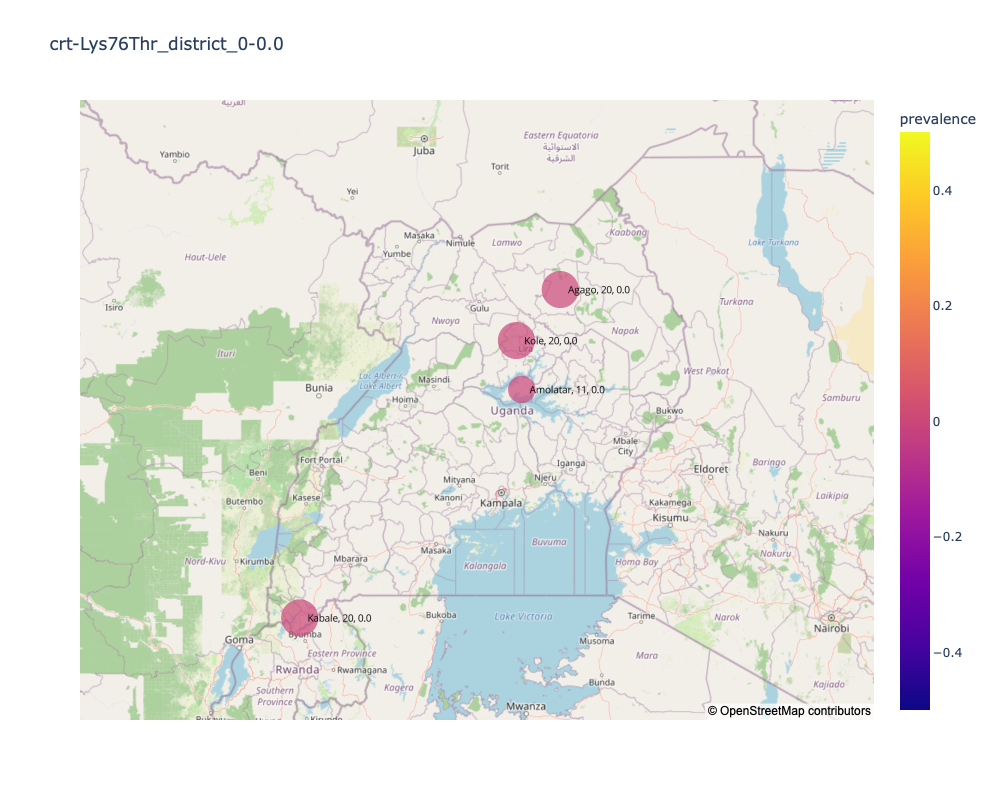

In [5]:
# Reads in a country using the dropdown menu above
# RUN
write_detail_files = write_detail_files_checkbox.value
use_geojson = use_geojson_checkbox.value
overlay_water = overlay_water_checkbox.value
highlight_chosen_country = highlight_chosen_country_checkbox.value
chosen_country = country.value
chosen_variant = variant.value
country_view = country_shortcuts[chosen_country]
zoom_level = country_view['zoom']
latitude = country_view['lat']
longitude = country_view['lon']

title_string=f'{chosen_variant}_{summary_column}'

# graphs the mutation of interest
fig = bg.make_detail_graph(
    chosen_variant,
    summary_column,
    output_folder,
    zoom_level,
    latitude,
    longitude,
    country_bounds=country_view['bounds'],
    chosen_country=chosen_country,
    overlay_water=overlay_water,
    highlight_chosen_country=highlight_chosen_country,
    use_geojson=use_geojson
)
print(zoom_level)
print(f"{latitude}, {longitude}")
fig.show(config={
    'toImageButtonOptions': {
        'format': 'svg',
        'filename': title_string,
        'height': 800,
        'width': 800,
        'scale': 1,
    }
})
if write_detail_files:
    bg.write_detail_graph_files(
        fig,
        output_folder,
        title_string,
        chosen_variant,
        summary_column,
        country_bounds=country_view['bounds'],
        chosen_country=chosen_country,
        overlay_water=overlay_water,
        highlight_chosen_country=highlight_chosen_country
    )